# Part 3: Customer Segmentation with K-Means Clustering

**Goal:** Group customers into segments based on annual spending, purchase frequency, and age, then suggest a marketing strategy for each segment.

**Model:** K-Means clustering (scikit-learn)

**Why K-Means?** There's no "correct answer" label here; we want the data to reveal natural groups. K-Means is a simple, widely used unsupervised method that assigns each customer to the nearest of K cluster centers.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42

## 2. Create the dataset

I generated 200 synthetic customers from three underlying customer types, with random variation around each:

| Type | Share | Avg annual spending | Avg purchases / yr |
|---|---|---|---|
| Budget | 40% | $1,200 | 4 |
| Average | 35% | $4,500 | 12 |
| High-value | 25% | $12,000 | 28 |

The model is **not** told which type each customer belongs to. The question is whether K-Means can find these groups on its own.

In [2]:
def generate_customer_data(n_records=200):
    rng = np.random.default_rng(RANDOM_SEED)
    archetypes = {
        "budget":     {"spending": 1200,  "frequency": 4,  "age": 35, "weight": 0.40},
        "average":    {"spending": 4500,  "frequency": 12, "age": 42, "weight": 0.35},
        "high_value": {"spending": 12000, "frequency": 28, "age": 38, "weight": 0.25},
    }
    names = list(archetypes)
    assignments = rng.choice(names, size=n_records, p=[archetypes[a]["weight"] for a in names])
    rows = []
    for a in assignments:
        p = archetypes[a]
        rows.append({
            "annual_spending": round(max(100, rng.normal(p["spending"], p["spending"] * 0.25)), 2),
            "purchase_frequency": round(max(1, rng.normal(p["frequency"], p["frequency"] * 0.3)), 1),
            "age": int(np.clip(rng.normal(p["age"], 10), 18, 75)),
            "region": rng.choice(["North", "South", "East", "West"]),
        })
    return pd.DataFrame(rows)

df = generate_customer_data()
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 4)


,annual_spending,purchase_frequency,age,region
0,13929.98,24.7,37,South
1,4879.77,17.1,42,North
2,13931.82,10.8,37,West
3,3128.84,8.8,38,East
4,1474.77,2.4,35,South


## 3. Scale the features

K-Means uses distance. Without scaling, `annual_spending` (in the thousands) would completely dominate `purchase_frequency` and `age` (in the tens). `StandardScaler` puts all three features on the same scale.

In [3]:
features = ["annual_spending", "purchase_frequency", "age"]
X_scaled = StandardScaler().fit_transform(df[features])

## 4. Choose the number of clusters (K)

I use two methods:

- **Elbow method:** plot inertia (how tightly packed the clusters are) for K = 1 to 8. The "elbow" is where adding more clusters stops helping much.
- **Silhouette score:** measures how well separated the clusters are (higher is better, max 1).

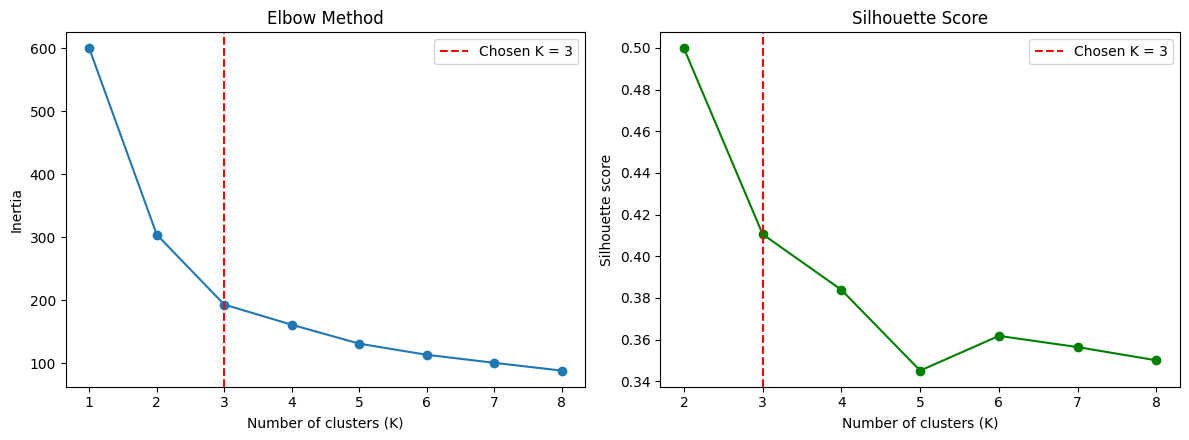

,inertia,silhouette
1,600.0,NaN
2,304.3,0.500
3,193.2,0.411
4,161.2,0.384
5,131.1,0.345
6,113.4,0.362
7,100.7,0.356
8,88.3,0.350


In [4]:
k_range = range(1, 9)
inertias, silhouettes = [], {}
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouettes[k] = silhouette_score(X_scaled, labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].axvline(3, color="red", linestyle="--", label="Chosen K = 3")
axes[0].set(title="Elbow Method", xlabel="Number of clusters (K)", ylabel="Inertia")
axes[0].legend()
axes[1].plot(list(silhouettes), list(silhouettes.values()), "o-", color="green")
axes[1].axvline(3, color="red", linestyle="--", label="Chosen K = 3")
axes[1].set(title="Silhouette Score", xlabel="Number of clusters (K)", ylabel="Silhouette score")
axes[1].legend()
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=120)
plt.show()

pd.DataFrame({"inertia": pd.Series(inertias, index=k_range).round(1),
              "silhouette": pd.Series(silhouettes).round(3)})

**Choosing K = 3:**

- The **elbow plot** bends at K = 3: inertia drops sharply up to 3 clusters and only slowly after that.
- The **silhouette score** is actually highest at K = 2. With 2 clusters, the high-value customers separate very cleanly from everyone else, but the budget and average customers get lumped together.
- I chose **K = 3** because it matches the elbow and gives more detail for marketing than a single "high-value vs. everyone else" split. The silhouette score at K = 3 (0.41) is still reasonable. Step 5 shows what that third cluster actually turned out to be.

## 5. Fit the final model and analyze the clusters

In [5]:
final_km = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=10)
df["cluster"] = final_km.fit_predict(X_scaled)

summary = df.groupby("cluster")[features].mean().round(1)
summary["count"] = df.groupby("cluster").size()
summary = summary.sort_values("annual_spending")
summary

,annual_spending,purchase_frequency,age,count
cluster,,,,
2,2425.7,6.2,27.4,66
1,3006.8,8.3,44.8,86
0,12862.8,27.7,38.7,48


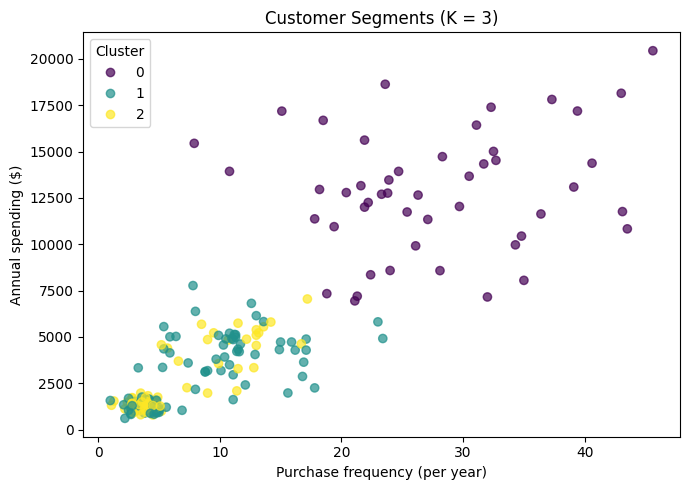

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df["purchase_frequency"], df["annual_spending"], c=df["cluster"], cmap="viridis", alpha=0.7)
ax.set(title="Customer Segments (K = 3)", xlabel="Purchase frequency (per year)", ylabel="Annual spending ($)")
ax.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

**What K-Means found (this was not what I expected):**

- **Cluster 0 (high-value, ~48 customers):** spends about $12.9k/yr and buys ~28 times/yr. This matches the high-value group built into the data almost exactly.
- **Clusters 1 and 2:** instead of splitting the remaining customers into "budget" and "average" by spending, K-Means split them **by age**. Both groups spend a similar amount (~$2.4k vs ~$3.0k), but Cluster 2 averages about 27 years old and Cluster 1 about 45.

**Why this happened:** after scaling, age counts just as much as spending in the distance calculation. The budget and average spending groups overlap a lot once random noise is added, while the spread in age is large, so the age split reduced inertia more. This is an important lesson: K-Means groups by whatever features you give it, and they carry equal weight after scaling. If the business goal were purely spend-based tiers, I would cluster on spending and frequency only.

## 6. Targeted marketing strategies

In [7]:
# Label clusters from the summary: highest spenders = high-value; the other two differ mainly by age
high_value = summary["annual_spending"].idxmax()
others = summary.drop(high_value).sort_values("age")
younger, older = others.index[0], others.index[1]

strategies = {
    high_value: "High-value frequent buyers: loyalty perks, exclusive promotions, early access to new products",
    younger: "Younger, lower-spending customers: social/mobile campaigns, first-purchase and bundle discounts to build frequency",
    older: "Older, lower-spending customers: email offers, value deals, free-shipping thresholds, loyalty points to grow spend",
}
for cluster_id in [high_value, younger, older]:
    row = summary.loc[cluster_id]
    print(f"Cluster {cluster_id} (n={int(row['count'])}, avg spend ${row['annual_spending']:,.0f}, avg age {row['age']:.0f}):")
    print(f"  -> {strategies[cluster_id]}")

df.to_csv("customer_segments.csv", index=False)

Cluster 0 (n=48, avg spend $12,863, avg age 39):
  -> High-value frequent buyers: loyalty perks, exclusive promotions, early access to new products
Cluster 2 (n=66, avg spend $2,426, avg age 27):
  -> Younger, lower-spending customers: social/mobile campaigns, first-purchase and bundle discounts to build frequency
Cluster 1 (n=86, avg spend $3,007, avg age 45):
  -> Older, lower-spending customers: email offers, value deals, free-shipping thresholds, loyalty points to grow spend


## 7. Limitations

- Because age is weighted equally with spending after scaling, it ended up defining two of the three clusters. Different feature choices (or weights) would give different segments.
- `region` isn't used because K-Means needs numeric features. It could be one-hot encoded, but region had no real pattern in this data.
- The data is synthetic with clear built-in groups, so K-Means has an easier job than it would with real customer data (e.g., the Kaggle Mall Customers dataset).